Training on 40 sites
Built 401472 total windows across all sites.
Train windows: 321177, Test windows: 80295


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 24, 64)              │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 407s 44ms/step - loss: 0.0039 - mae: 0.0417 - val_loss: 0.0015 - val_mae: 0.0248
Epoch 2/5
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 406s 45ms/step - loss: 0.0019 - mae: 0.0300 - val_loss: 0.0013 - val_mae: 0.0241
Epoch 3/5
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 404s 45ms/step - loss: 0.0018 - mae: 0.0296 - val_loss: 0.0012 - val_mae: 0.0225
Epoch 4/5
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 445s 45ms/step - loss: 0.0016 - mae: 0.0276 - val_loss: 0.0011 - val_mae: 0.0220
Epoch 5/5
9034/9034 ━━━━━━━━━━━━━━━━━━━━ 450s 46ms/step - loss: 0.0015 - mae: 0.0271 - val_loss: 0.0012 - val_mae: 0.0236


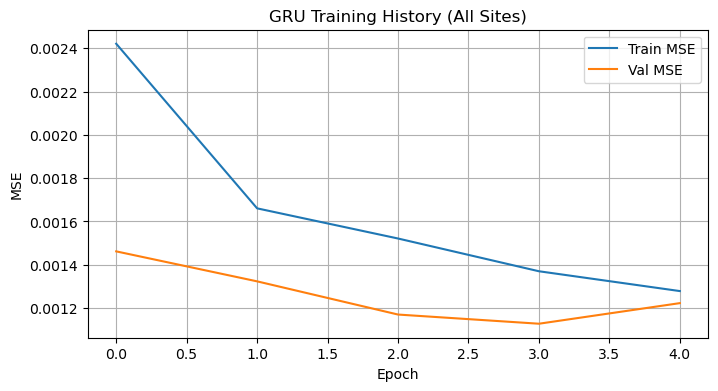


RMSE: 24.51
R² Score: 0.8849

 Model saved as gru_model_all.h5


In [4]:
# train_global_gru_all.py

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ─── CONFIG ──────────────────────────────────────────────────────────────
DATA_PATH = '../data/traffic_cleaned.csv'
SEQ_LEN     = 24
TEST_SPLIT  = 0.2
BATCH_SIZE  = 32
EPOCHS      = 5          # increase for full training
PATIENCE    = 5
MODELS_DIR  = '../models' 
MODEL_FN    = 'gru_model_all.h5'
SCALER_FN   = 'scaler_all.pkl'
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(MODELS_DIR, exist_ok=True)
np.random.seed(42)

# 1) Load & sort full dataset
df = pd.read_csv(DATA_PATH, parse_dates=['DateTime'])
df.sort_values(['SCATS Number','DateTime'], inplace=True)

# 2) Build sliding windows across ALL SCATS sites
X_windows, y_windows = [], []
site_ids = df['SCATS Number'].unique()
print(f"Training on {len(site_ids)} sites")

for site in site_ids:
    sub = df[df['SCATS Number']==site].set_index('DateTime')
    flows = sub['Traffic_flow'].values
    for i in range(len(flows) - SEQ_LEN):
        X_windows.append(flows[i:i+SEQ_LEN])
        y_windows.append(flows[i+SEQ_LEN])

X = np.array(X_windows)[:,:,None]   # shape = (samples, SEQ_LEN,1)
y = np.array(y_windows)[:,None]     # shape = (samples,1)
print(f"Built {X.shape[0]} total windows across all sites.")

# 3) Global scaling
scaler = MinMaxScaler()
flat_X = X.reshape(-1,1)
scaler.fit(np.vstack([flat_X, y]))
X_scaled = scaler.transform(flat_X).reshape(X.shape)
y_scaled = scaler.transform(y)

# 4) Train/test split
n = len(X_scaled)
split = int(n * (1 - TEST_SPLIT))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]
print(f"Train windows: {X_train.shape[0]}, Test windows: {X_test.shape[0]}")

# 5) Build GRU model
model = Sequential([
    GRU(64, input_shape=(SEQ_LEN,1), return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# 6) Train with early stopping
es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    shuffle=False,
    verbose=1   # real-time progress
)

# 7) Plot train/val loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('GRU Training History (All Sites)')
plt.legend()
plt.grid(True)
plt.show()

# 8) Evaluate on test set (RMSE & R²)
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"\nRMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 9) Save model and scaler
model.save(os.path.join(MODELS_DIR, MODEL_FN))
with open(os.path.join(MODELS_DIR, SCALER_FN), 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n Model saved as {MODEL_FN}")
